feature neutralization

In [5]:
import sys

!{sys.executable} -m pip uninstall -y pandas pyarrow
!{sys.executable} -m pip install --no-cache-dir pandas pyarrow

Found existing installation: pandas 3.0.1
Uninstalling pandas-3.0.1:
  Successfully uninstalled pandas-3.0.1
Found existing installation: pyarrow 24.0.0
Uninstalling pyarrow-24.0.0:
  Successfully uninstalled pyarrow-24.0.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 2.3 MB/s  0:00:04m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.0/35.0 MB 2.0 MB/s  0:00:17m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [pandas]2m1/2 [pandas]

[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [2]:
import pandas as pd

train_path = "/Users/seomichelle/26-1 ESAA:Python/datasets/프로젝트/train.parquet"

train = pd.read_parquet(train_path)

train.head()

,era,data_type,feature_shaded_hallucinatory_dactylology,feature_itinerant_hexahedral_photoengraver,feature_prudent_pileate_oven,feature_subalpine_apothegmatical_ajax,feature_pistachio_atypical_malison,feature_symmetrical_spongy_tricentenary,feature_ungrounded_transpontine_winder,feature_aseptic_eely_hemiplegia,...,target_teager2b_20,target_teager2b_60,target_tyler_20,target_tyler_60,target_victor_20,target_victor_60,target_waldo_20,target_waldo_60,target_xerxes_20,target_xerxes_60
id,,,,,,,,,,,,,,,,,,,,,
n0007b5abb0c3a25,0001,train,3,4,0,3,3,1,1,0,...,0.50,0.50,0.25,0.25,0.25,0.25,0.25,0.00,0.25,0.00
n003bba8a98662e4,0001,train,4,2,4,4,0,0,4,4,...,0.50,0.50,0.25,0.25,0.25,0.00,0.25,0.25,0.25,0.25
n003bee128c2fcfc,0001,train,2,4,0,3,0,3,2,4,...,1.00,1.00,1.00,0.75,0.75,0.75,0.75,1.00,0.75,0.75
n0048ac83aff7194,0001,train,2,1,3,0,3,0,3,3,...,0.25,0.25,0.25,0.25,0.50,0.25,0.25,0.25,0.25,0.25
n0055a2401ba6480,0001,train,4,1,4,1,0,4,0,4,...,0.50,0.50,0.25,0.50,0.25,0.50,0.25,0.50,0.25,0.50


In [3]:
import numpy as np
import pandas as pd

feature_cols = [col for col in train.columns if col.startswith("feature_")]
target_cols = [col for col in train.columns if col.startswith("target_")]

print("feature 개수:", len(feature_cols))
print("target 개수:", len(target_cols))

feature 개수: 2748
target 개수: 40



전처리 전 데이터 일부


,era,target_agnes_20
id,,
n0007b5abb0c3a25,0001,0.25
n003bba8a98662e4,0001,0.25
n003bee128c2fcfc,0001,1.00
n0048ac83aff7194,0001,0.25
n0055a2401ba6480,0001,0.25



전처리 전/후 데이터 일부


,era,target_agnes_20,target_agnes_20_neutralized
id,,,
n0007b5abb0c3a25,0001,0.25,-0.911288
n003bba8a98662e4,0001,0.25,-1.067090
n003bee128c2fcfc,0001,1.00,2.267221
n0048ac83aff7194,0001,0.25,-1.111735
n0055a2401ba6480,0001,0.25,-1.277541



전처리 전/후 통계 비교


,target_agnes_20,target_agnes_20_neutralized,neutralization_diff
count,2.746268e+06,2.746268e+06,2.746268e+06
mean,5.000864e-01,-4.708891e-18,-5.000864e-01
std,2.225466e-01,9.999956e-01,7.801136e-01
min,0.000000e+00,-2.939473e+00,-2.939473e+00
25%,2.500000e-01,-6.219976e-01,-9.606296e-01
50%,5.000000e-01,-2.748512e-04,-5.002749e-01
75%,7.500000e-01,5.789171e-01,-4.678455e-02
max,1.000000e+00,2.908429e+00,1.908429e+00



NaN 개수
target_agnes_20                0
target_agnes_20_neutralized    0
dtype: int64

무한값 개수
target_agnes_20                0
target_agnes_20_neutralized    0
dtype: int64


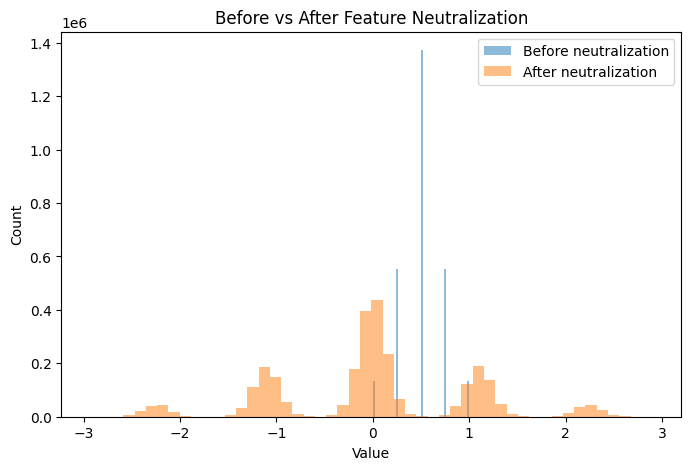

In [8]:
# =========================
# Feature neutralization 함수
# =========================

def neutralize_by_era(
    df,
    columns,
    neutralizers,
    era_col="era",
    proportion=0.5,
    normalize=True
):
    result = []

    for era, era_df in df.groupby(era_col, sort=False):
        scores = era_df[columns].values.astype(np.float64)
        exposures = era_df[neutralizers].values.astype(np.float64)

        # NaN, inf 처리
        scores = np.nan_to_num(scores, nan=0.0, posinf=0.0, neginf=0.0)
        exposures = np.nan_to_num(exposures, nan=0.0, posinf=0.0, neginf=0.0)

        # era별 feature 표준화
        exposures = exposures - exposures.mean(axis=0)
        exposures = exposures / (exposures.std(axis=0) + 1e-6)

        # 상수항 추가
        exposures = np.hstack([
            exposures,
            np.ones((exposures.shape[0], 1))
        ])

        # scores에서 feature로 설명되는 부분 제거
        correction = exposures @ np.linalg.lstsq(exposures, scores, rcond=None)[0]
        neutralized = scores - proportion * correction

        # neutralized 값 정규화
        if normalize:
            neutralized = neutralized - neutralized.mean(axis=0)
            neutralized = neutralized / (neutralized.std(axis=0) + 1e-6)

        neutralized_df = pd.DataFrame(
            neutralized,
            index=era_df.index,
            columns=[col + "_neutralized" for col in columns]
        )

        result.append(neutralized_df)

    return pd.concat(result).loc[df.index]


# =========================
# 확인용 데이터 만들기
# =========================

check_df = train[["era", target_col] + sample_features].copy()

print("\n전처리 전 데이터 일부")
display(check_df[["era", target_col]].head())


# =========================
#  target에 feature neutralization 적용
# =========================

neutralized_result = neutralize_by_era(
    df=check_df,
    columns=[target_col],
    neutralizers=sample_features,
    era_col="era",
    proportion=0.5,
    normalize=True
)

check_df = pd.concat([check_df, neutralized_result], axis=1)

neutralized_col = target_col + "_neutralized"

print("\n전처리 전/후 데이터 일부")
display(check_df[["era", target_col, neutralized_col]].head())


# =========================
#  값이 실제로 바뀌었는지 확인
# =========================

check_df["neutralization_diff"] = check_df[neutralized_col] - check_df[target_col]

print("\n전처리 전/후 통계 비교")
display(check_df[[target_col, neutralized_col, "neutralization_diff"]].describe())


# =========================
# 결측치 확인
# =========================

print("\nNaN 개수")
print(check_df[[target_col, neutralized_col]].isna().sum())

print("\n무한값 개수")
print(np.isinf(check_df[[target_col, neutralized_col]]).sum())

# =========================
#  분포 그래프 확인
# =========================

plt.figure(figsize=(8, 5))
plt.hist(check_df[target_col], bins=50, alpha=0.5, label="Before neutralization")
plt.hist(check_df[neutralized_col], bins=50, alpha=0.5, label="After neutralization")
plt.title("Before vs After Feature Neutralization")
plt.xlabel("Value")
plt.ylabel("Count")
plt.legend()
plt.show()
